«El objetivo del fine-tuning no es alterar radicalmente el modelo base, sino proporcionarle un ajuste sutil (empujoncito) para que reconozca patrones y características específicas dentro de un corpus de texto determinado. Para evaluar este comportamiento, realizamos pruebas utilizando tres tasas de aprendizaje (learning rates) diferentes, apoyándonos inicialmente en métricas cuantitativas de entrenamiento. Sin embargo, los resultados numéricos por sí solos resultan informativos pero insuficientes para tomar decisiones de despliegue en un entorno de producción real, donde la validación cualitativa se vuelve indispensable»

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Importar las clases necesarias de la librería Transformers de Hugging Face
# AutoModelForCausalLM permite cargar modelos preentrenados de lenguaje causal (como GPT-2)
# GPT2Tokenizer se encarga de tokenizar el texto específicamente para la arquitectura GPT-2
from transformers import AutoModelForCausalLM, GPT2Tokenizer

# Importar requests para realizar solicitudes HTTP (útil para descargar el texto del libro desde la web)
import requests

# Gráficos vectoriales
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [8]:
# Cargar el modelo preentrenado GPT-2 y su tokenizador
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

# Hiperparámetros
seq_len = 256  # Longitud máxima de secuencia
batch_size = 16

# Usar GPU si está disponible
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [9]:
# Tokenizar el texto de Los viajes de Gulliver :)
text = requests.get(
    'https://www.gutenberg.org/cache/epub/829/pg829.txt'
).text

# La forma antigua:
gtTokens = torch.tensor(tokenizer.encode(text), dtype=torch.long)
print(gtTokens.shape)

# Una forma mejor ;)
gtTokens = tokenizer.encode(text, return_tensors='pt') #pt por pytorch
print(gtTokens.shape)

# Pero el resto del código está configurado para tensores sin dimensión (1D)
gtTokens = gtTokens[0] # estamos accediento a la 1 fila que es el unsqueeze del tensor
print(gtTokens.shape)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (158340 > 1024). Running this sequence through the model will result in indexing errors


torch.Size([158340])
torch.Size([1, 158340])
torch.Size([158340])


In [10]:
# Encontrar los 100 tokens más frecuentes
uniq, counts = np.unique(gtTokens, return_counts=True) # devolver lso tokens unicos y retonar los conteos (TRUE)
freqidx = np.argsort(counts)[::-1] #slicing para invertir el orden
top100 = uniq[freqidx[:100]] # todos hasta los 100

for t in top100:
  print(
      f'Token {t:5} aparece {torch.sum(gtTokens==t):4} veces y es'  # Muestra el ID del token reservando 5 espacios de ancho para alinear la columna / # Cuenta las apariciones totales de ese token en el tensor reservando 4 espacios
      f' "{tokenizer.decode(t)}"'  # Traduce el ID numérico de vuelta a texto legible usando el tokenizador
)

Token    11 aparece 10060 veces y es ","
Token   198 aparece 9923 veces y es "
"
"
Token   262 aparece 5393 veces y es " the"
Token   286 aparece 3779 veces y es " of"
Token   290 aparece 3468 veces y es " and"
Token   284 aparece 3356 veces y es " to"
Token    13 aparece 3006 veces y es "."
Token   314 aparece 2657 veces y es " I"
Token   257 aparece 2431 veces y es " a"
Token   287 aparece 1900 veces y es " in"
Token    26 aparece 1562 veces y es ";"
Token   616 aparece 1474 veces y es " my"
Token   373 aparece 1199 veces y es " was"
Token   326 aparece 1061 veces y es " that"
Token   502 aparece  964 veces y es " me"
Token   351 aparece  941 veces y es " with"
Token   355 aparece  920 veces y es " as"
Token   465 aparece  823 veces y es " his"
Token   416 aparece  794 veces y es " by"
Token   329 aparece  776 veces y es " for"
Token   543 aparece  774 veces y es " which"
Token   447 aparece  734 veces y es "�"
Token   340 aparece  718 veces y es " it"
Token   307 aparece  698 veces 

Aca lo hicimos como una funcion para tener 3 diferentes modelos con 3 diferentes Learning rates

In [13]:
def countFreqTokens(model):
  # Tokens de inicio aleatorios
  numreps = 10  # Número de repeticiones aleatorias
  numtoks = 100  # Longitud de la salida
  randstarts = torch.randint(
      tokenizer.vocab_size, (numreps, 1)
  ).to(device)  #

  # Generar algunos datos
  out = model.generate(
      randstarts,
      max_length=numtoks + 1,
      min_length=numtoks + 1,
      do_sample=True,
      bad_words_ids=[tokenizer.encode(tokenizer.eos_token)],
      pad_token_id=tokenizer.encode(tokenizer.eos_token)[0],
  ).cpu()  #

  # Retornar la proporción (porcentaje) de tokens frecuentes utilizados
  return np.mean(100 * np.isin(out[:, 1:], top100).flatten())

In [14]:
def trainTheModel(lr, num_samples):
  # Descargar una copia limpia del modelo
  gpt2 = AutoModelForCausalLM.from_pretrained('gpt2').to(device)  #[cite: 4]

  # Evaluación previa al entrenamiento
  pretrainEval = countFreqTokens(gpt2)  #[cite: 4]

  # Crear las funciones del optimizador
  optimizer = torch.optim.AdamW(
      gpt2.parameters(), lr=lr, weight_decay=0.01
  )  #[cite: 4]

  # Inicializar las pérdidas
  train_loss = np.zeros(num_samples)  #[cite: 4]

  ### Ahora comienza el entrenamiento
  for sampli in range(num_samples):  #[cite: 5]

    # Obtener un lote de datos
    ix = torch.randint(len(gtTokens) - seq_len, size=(batch_size,))  #[cite: 5]
    X = gtTokens[
        ix[:, None] + torch.arange(seq_len)
    ].to(device)  #[cite: 5]

    # Propagación hacia adelante (Hugging Face desplaza X internamente para obtener y)
    gpt2.zero_grad()  #[cite: 5]
    outputs = gpt2(X, labels=X)  #[cite: 5]
    loss = outputs.loss  #[cite: 5]

    # Retropropagación
    loss.backward()  #[cite: 5]
    optimizer.step()  #[cite: 5]

    # Almacenar la pérdida por muestra
    train_loss[sampli] = loss.item()  #[cite: 5, 6]

  # Evaluación posterior al entrenamiento
  psttrainEval = countFreqTokens(gpt2)  #[cite: 6]

  return train_loss, pretrainEval, psttrainEval  #[cite: 6]

## Learning rate

In [15]:
learningRates = [1e-4, 1e-5, 1e-6]  #[cite: 7]
training_samples = 800  #[cite: 7]

evalsPcts = np.zeros((3, 2))  #[cite: 7]
losses = []  #[cite: 7]

for idx, lr in enumerate(learningRates):  #[cite: 7]
  # Entrenar un modelo nuevo y obtener los resultados
  train_loss, pretrainEval, psttrainEval = trainTheModel(
      lr, training_samples
  )  #[cite: 7]

  # Almacenar los resultados
  evalsPcts[idx, 0] = pretrainEval  #[cite: 7]
  evalsPcts[idx, 1] = psttrainEval  #[cite: 7]
  losses.append(train_loss)  #[cite: 7]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] The attention mask is not set with a batched input, and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

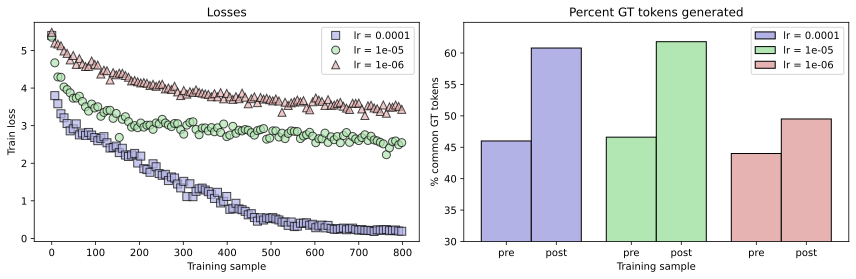

In [18]:
# Crear una figura con 1 fila y 2 columnas para las gráficas
_, axs = plt.subplots(1, 2, figsize=(12, 4))  #[cite: 9]

colors = [[.7, .7, .9], [.7, .9, .7], [.9, .7, .7]]  #[cite: 9]
shapes = 'so^'  #[cite: 9]

# Bucle para graficar los resultados de cada tasa de aprendizaje
for i in range(3):  #[cite: 9]

  # Graficar las pérdidas de entrenamiento en la primera subtrama
  axs[0].plot(
      range(0, training_samples, 7),
      losses[i][::7],
      f'k{shapes[i]}',
      markerfacecolor=colors[i],
      alpha=.7,
      markersize=8,
      label=f'lr = {learningRates[i]}',
  )  #[cite: 9]

  # Graficar el porcentaje de tokens comunes en la segunda subtrama
  axs[1].bar(
      [i - .2, i + .2],
      evalsPcts[i, :],
      width=.4,
      edgecolor='k',
      facecolor=colors[i],
      label=f'lr = {learningRates[i]}',
  )  #[cite: 10]

# Configurar etiquetas y títulos de la primera gráfica (Pérdidas)
axs[0].set(
    xlabel='Training sample', ylabel='Train loss', title='Losses'
)  #[cite: 10]
axs[0].legend()  #[cite: 10]

# Configurar etiquetas, marcas y límites de la segunda gráfica (Porcentaje de tokens)
axs[1].set(
    xlabel='Training sample',
    xticks=[-.2, .2, .8, 1.2, 1.8, 2.2],
    xticklabels=['pre', 'post', 'pre', 'post', 'pre', 'post'],
    title='Percent GT tokens generated',
    ylabel='% common GT tokens',
    ylim=[30, None],
)  #[cite: 10]
axs[1].legend()  #[cite: 10]

# Ajustar diseño de la figura y mostrarla en pantalla
plt.tight_layout()  #[cite: 10]
plt.show()  #[cite: 10]

###  Análisis de los Resultados

1. **Curvas de Pérdida (*Train Loss* - Gráfica Izquierda):**
* **Tasa alta ($lr = 0.0001$, cuadrados morados):** Muestra un descenso rápido y profundo de la pérdida, acercándose casi a cero hacia el final de las 800 muestras. Esto indica que el modelo está aprendiendo y adaptándose agresivamente al texto de *Gulliver's Travels*.


* **Tasa media ($lr = 1\text{e-}5$, círculos verdes):** Presenta una caída moderada y estable, estabilizándose en un nivel intermedio de pérdida (alrededor de 2.5).


* **Tasa baja ($lr = 1\text{e-}6$, triángulos rojos):** La pérdida apenas desciende de manera muy conservadora, manteniéndose en valores altos (cercanos a 3.5). El modelo apenas modifica sus pesos iniciales.




2. **Porcentaje de Tokens Comunes Generados (*Percent GT tokens generated* - Gráfica Derecha):**
* **Estado Pre-entrenamiento (*pre*):** Todos los modelos parten de un valor base similar (entre el 44% y el 46%) antes de recibir el ajuste fino.


* **Estado Post-entrenamiento (*post*):** Tras procesar las 800 muestras, todos incrementan el uso de tokens característicos del texto de referencia.
* Las tasas de $lr = 0.0001$ y $lr = 1\text{e-}5$ logran los mayores incrementos, superando el 60% de similitud con el estilo del texto.


* La tasa más baja ($lr = 1\text{e-}6$) muestra un incremento más tímido, quedándose por debajo del 50%.







---

###  Conclusión

El análisis demuestra que **la tasa de aprendizaje ($learning\ rate$) es el hiperparámetro crítico** que define el éxito del *fine-tuning*:

* Una tasa demasiado baja ($1\text{e-}6$) es insuficiente para que el modelo internalice las características particulares del nuevo texto.
* Una tasa agresiva u óptima ($0.0001$ o $1\text{e-}5$) logra reducir la pérdida de forma efectiva y eleva notablemente la capacidad del modelo para replicar el vocabulario y estilo objetivo.



Sin embargo, las cifras cuantitativas por sí solas solo muestran que el modelo memorizó o se adaptó numéricamente; la decisión final de despliegue requerirá siempre una validación cualitativa para confirmar que el texto generado mantiene coherencia y sentido real.

---

Siguientes pasos recomendados para avanzar con la optimización y validación cualitativa del modelo.